<a href="https://colab.research.google.com/github/RamitSachdev/IML_Assignment1/blob/main/IML_A1_Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

# Loading the dataset, extracting the images and labels and then Normalizing to [0,1]
dataset = load_dataset("zalando-datasets/fashion_mnist")

train_data = dataset["train"]
test_data  = dataset["test"]


X_train = np.array([np.array(img).flatten() for img in train_data["image"]], dtype=np.float32)
y_train = np.array(train_data["label"])

X_test = np.array([np.array(img).flatten() for img in test_data["image"]], dtype=np.float32)
y_test = np.array(test_data["label"])


X_train = X_train / 255.0
X_test  = X_test  / 255.0

print(f"X_train shape: {X_train.shape}")  # (60000, 784)
print(f"X_test shape:  {X_test.shape}")   # (10000, 784)
print(f"Classes: {np.unique(y_train)}")

class_names = ["T-shirt/top","Trouser","Pullover","Dress","Coat",
               "Sandal","Shirt","Sneaker","Bag","Ankle boot"]

X_train shape: (60000, 784)
X_test shape:  (10000, 784)
Classes: [0 1 2 3 4 5 6 7 8 9]


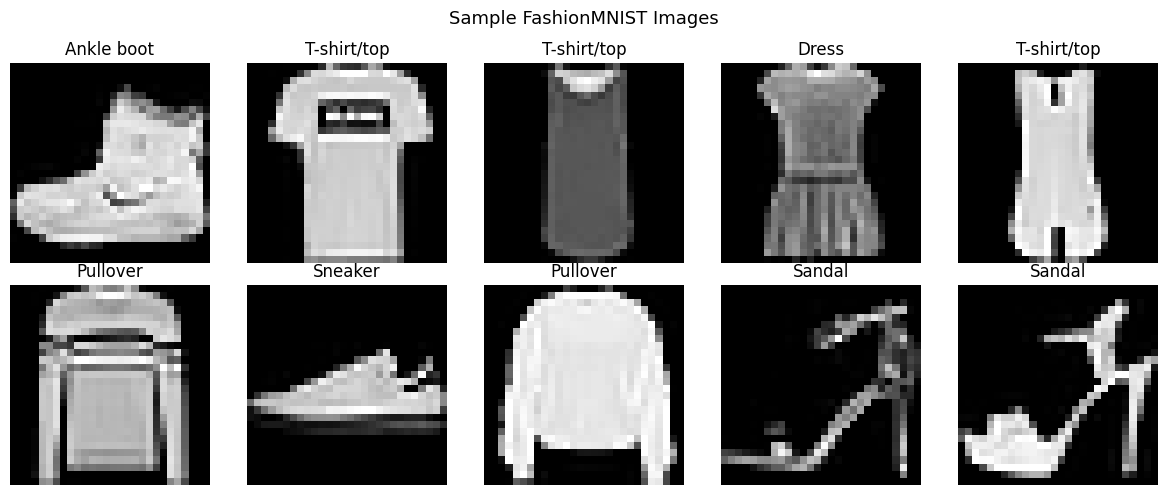

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(X_train[i].reshape(28, 28), cmap="gray")
    ax.set_title(class_names[y_train[i]])
    ax.axis("off")
plt.suptitle("Sample FashionMNIST Images", fontsize=13)
plt.tight_layout()
plt.show()

In [10]:
def softmax(Z):
    Z = Z - np.max(Z, axis=1, keepdims=True)
    expZ = np.exp(Z)
    return expZ / np.sum(expZ, axis=1, keepdims=True)

def one_hot(y, n_classes):
    n = len(y)
    Y = np.zeros((n, n_classes))
    Y[np.arange(n), y] = 1
    return Y

def cross_entropy_loss(Y_hat, Y_one_hot):
    Y_hat = np.clip(Y_hat, 1e-12, 1.0) #this will avoid 0 (done with help og gpt)
    return -np.mean(np.sum(Y_one_hot * np.log(Y_hat), axis=1))

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [11]:
def compute_gradients(X, Y_one_hot, W, b):
    """
    Forward pass: Z = X @ W + b, Y_hat = softmax(Z)
    Loss = cross entropy
    Gradients derived from the notes:
        dL/dW = (1/n) * X^T @ (Y_hat - Y)
        dL/db = (1/n) * sum(Y_hat - Y, axis=0)
    """
    n = X.shape[0]
    Z     = X @ W + b
    Y_hat = softmax(Z)
    diff  = Y_hat - Y_one_hot
    dW    = (X.T @ diff) / n
    db    = np.mean(diff, axis=0)
    loss  = cross_entropy_loss(Y_hat, Y_one_hot)
    return dW, db, loss

def predict(X, W, b):
    Z     = X @ W + b
    Y_hat = softmax(Z)
    return np.argmax(Y_hat, axis=1)

#was facing too many errors for gradient and had to take help from claude and gemini

In [12]:
def train(X_train, y_train, X_test, y_test,
          n_classes=10, lr=0.1, epochs=50, batch_size=256):

    n_features = X_train.shape[1]
    n_train    = X_train.shape[0]

    # we keep bias zero at intialising
    W = np.random.randn(n_features, n_classes) * 0.01
    b = np.zeros(n_classes)

    Y_one_hot = one_hot(y_train, n_classes)

    train_losses = []
    test_losses  = []
    train_accs   = []
    test_accs    = []

#Now, since we want to shuffle the data after each epoch, we run a for loop
    for epoch in range(epochs):
        perm = np.random.permutation(n_train)
        X_shuffled = X_train[perm]
        Y_shuffled = Y_one_hot[perm]

        epoch_loss = 0
        n_batches  = 0

        for start in range(0, n_train, batch_size):
            end     = start + batch_size
            X_batch = X_shuffled[start:end]
            Y_batch = Y_shuffled[start:end]

            dW, db, loss = compute_gradients(X_batch, Y_batch, W, b)

            # update for gd
            W = W - lr * dW
            b = b - lr * db

            epoch_loss += loss
            n_batches  += 1

        # at end of each epoch we record them
        avg_loss = epoch_loss / n_batches
        train_losses.append(avg_loss)

        # test loss
        Z_test     = X_test @ W + b
        Yhat_test  = softmax(Z_test)
        Y_test_oh  = one_hot(y_test, n_classes)
        t_loss     = cross_entropy_loss(Yhat_test, Y_test_oh)
        test_losses.append(t_loss)

        # accuracies
        train_acc = accuracy(y_train, predict(X_train, W, b))
        test_acc  = accuracy(y_test,  predict(X_test,  W, b))
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} | "
                  f"Train Loss: {avg_loss:.4f} | Test Loss: {t_loss:.4f} | "
                  f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

    return W, b, train_losses, test_losses, train_accs, test_accs

np.random.seed(42)
W, b, train_losses, test_losses, train_accs, test_accs = train(
    X_train, y_train, X_test, y_test,
    n_classes=10, lr=0.1, epochs=50, batch_size=256
)

# for test loss and accuracies, debugging was done using gpt

Epoch 5/50 | Train Loss: 0.4862 | Test Loss: 0.5150 | Train Acc: 0.8357 | Test Acc: 0.8226
Epoch 10/50 | Train Loss: 0.4483 | Test Loss: 0.4883 | Train Acc: 0.8451 | Test Acc: 0.8312
Epoch 15/50 | Train Loss: 0.4299 | Test Loss: 0.4716 | Train Acc: 0.8521 | Test Acc: 0.8371
Epoch 20/50 | Train Loss: 0.4206 | Test Loss: 0.4567 | Train Acc: 0.8581 | Test Acc: 0.8387
Epoch 25/50 | Train Loss: 0.4130 | Test Loss: 0.4566 | Train Acc: 0.8573 | Test Acc: 0.8394
Epoch 30/50 | Train Loss: 0.4072 | Test Loss: 0.4497 | Train Acc: 0.8615 | Test Acc: 0.8427
Epoch 35/50 | Train Loss: 0.4032 | Test Loss: 0.4545 | Train Acc: 0.8591 | Test Acc: 0.8384
Epoch 40/50 | Train Loss: 0.4007 | Test Loss: 0.4549 | Train Acc: 0.8577 | Test Acc: 0.8387
Epoch 45/50 | Train Loss: 0.3977 | Test Loss: 0.4837 | Train Acc: 0.8456 | Test Acc: 0.8230
Epoch 50/50 | Train Loss: 0.3949 | Test Loss: 0.4518 | Train Acc: 0.8613 | Test Acc: 0.8420


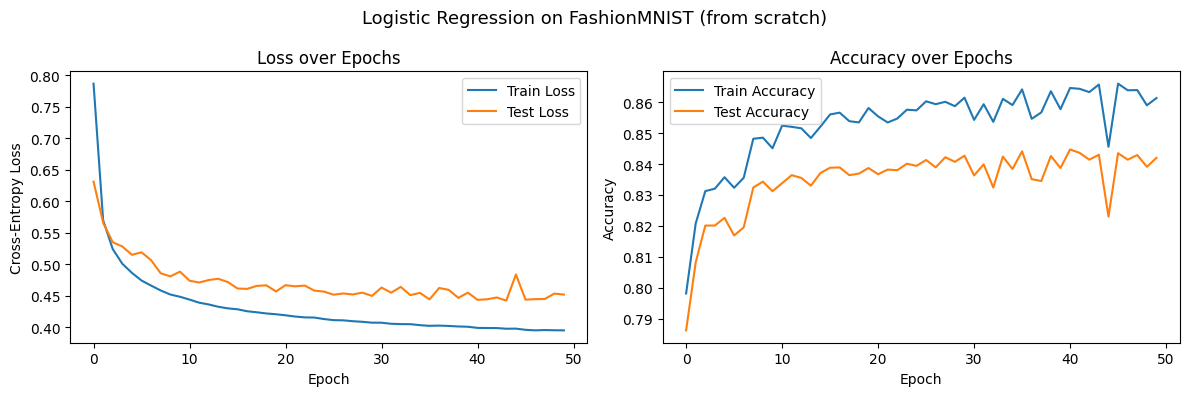

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label="Train Loss")
axes[0].plot(test_losses,  label="Test Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].set_title("Loss over Epochs")
axes[0].legend()

axes[1].plot(train_accs, label="Train Accuracy")
axes[1].plot(test_accs,  label="Test Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy over Epochs")
axes[1].legend()

plt.suptitle("Logistic Regression on FashionMNIST (from scratch)", fontsize=13)
plt.tight_layout()
plt.show()

Final Test Accuracy: 84.20%


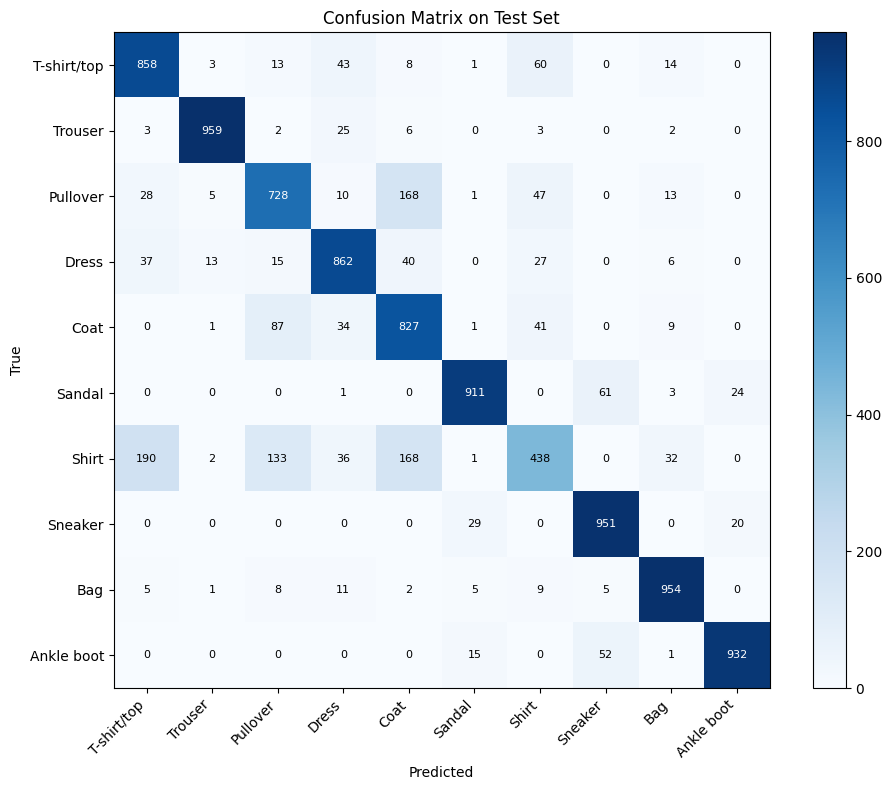


Per-class accuracy:
  T-shirt/top    : 85.80%
  Trouser        : 95.90%
  Pullover       : 72.80%
  Dress          : 86.20%
  Coat           : 82.70%
  Sandal         : 91.10%
  Shirt          : 43.80%
  Sneaker        : 95.10%
  Bag            : 95.40%
  Ankle boot     : 93.20%


In [14]:
# Final accuracy
y_pred = predict(X_test, W, b)
final_acc = accuracy(y_test, y_pred)
print(f"Final Test Accuracy: {final_acc * 100:.2f}%")

# Confusion matrix manually
n_classes = 10
conf_matrix = np.zeros((n_classes, n_classes), dtype=int)
for true, pred in zip(y_test, y_pred):
    conf_matrix[true][pred] += 1

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(conf_matrix, cmap="Blues")
ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion Matrix on Test Set")

for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, str(conf_matrix[i, j]),
                ha="center", va="center",
                color="white" if conf_matrix[i, j] > conf_matrix.max() * 0.5 else "black",
                fontsize=8)

plt.colorbar(im)
plt.tight_layout()
plt.show()

# Per class accuracy
print("\nPer-class accuracy:")
for i in range(n_classes):
    class_acc = conf_matrix[i, i] / conf_matrix[i].sum()
    print(f"  {class_names[i]:<15}: {class_acc*100:.2f}%")


#prepared with help of gemini